# Tehtävä päätöspuut ja satunnaismetsä

# Osa 1: päätöspuu

# 1. Business understanding

Tavoitteena on löytää matalin ja selkein päätöspuu IT-asiantuntijalle firmassa. Puu ennustaa onko sivu phishing vai ei. Tässä ei valita parasta puuta eli syvintä vaan paras ja lyhyin puu

In [1]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 2. Data understanding

Phishing Websites -aineisto ladataan UCI Machine Learning Repositorysta.

Kohdemuuttuja on Result.

Ennen mallin rakentamista aineistoa tutkitaan, jotta saadaan käsitys seuraavista asioista:

- havaintojen määrä
- selittävien muuttujien määrä
- muuttujien nimet
- datatyypit
- puuttuvat arvot
- kohdemuuttujan luokkajakauma

In [3]:
pd.set_option("display.max_columns", None)
  
# fetch dataset 
phishing_websites = fetch_ucirepo(id=327) 
  
# data (as pandas dataframes) 
x = phishing_websites.data.features 
y = phishing_websites.data.targets 
  
# metadata 
print(phishing_websites.metadata) 
  
# variable information 
print(phishing_websites.variables) 

{'uci_id': 327, 'name': 'Phishing Websites', 'repository_url': 'https://archive.ics.uci.edu/dataset/327/phishing+websites', 'data_url': 'https://archive.ics.uci.edu/static/public/327/data.csv', 'abstract': 'This dataset collected mainly from: PhishTank archive, MillerSmiles archive, Googleâ€™s searching operators.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 11055, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['result'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Tue Mar 05 2024', 'dataset_doi': '10.24432/C51W2X', 'creators': ['Rami Mohammad', 'Lee McCluskey'], 'intro_paper': {'ID': 396, 'type': 'NATIVE', 'title': 'An assessment of features related to phishing websites using an automated technique', 'authors': 'R. Mohammad, F. Thabtah, L. Mccluskey', 'venue': 'International Conference for Internet Tec

In [4]:
df = pd.concat([x, y], axis=1)

df.dtypes

having_ip_address             int64
url_length                    int64
shortining_service            int64
having_at_symbol              int64
double_slash_redirecting      int64
prefix_suffix                 int64
having_sub_domain             int64
sslfinal_state                int64
domain_registration_length    int64
favicon                       int64
port                          int64
https_token                   int64
request_url                   int64
url_of_anchor                 int64
links_in_tags                 int64
sfh                           int64
submitting_to_email           int64
abnormal_url                  int64
redirect                      int64
on_mouseover                  int64
rightclick                    int64
popupwindow                   int64
iframe                        int64
age_of_domain                 int64
dnsrecord                     int64
web_traffic                   int64
page_rank                     int64
google_index                

## Puuttuvat arvot

Tutkitaan ja varmistetaan että datassa ei ole puuttuvia arvoja.

In [5]:
print("Puuttuvat arvot featuresista:")
display(x.isnull().sum())

print("Puuttuvien arvojen yhteissumma featuresista:")
print(x.isnull().sum().sum())

print("Puuttuvat targetin arvot:")
print(y.isnull().sum().sum())

Puuttuvat arvot featuresista:


having_ip_address             0
url_length                    0
shortining_service            0
having_at_symbol              0
double_slash_redirecting      0
prefix_suffix                 0
having_sub_domain             0
sslfinal_state                0
domain_registration_length    0
favicon                       0
port                          0
https_token                   0
request_url                   0
url_of_anchor                 0
links_in_tags                 0
sfh                           0
submitting_to_email           0
abnormal_url                  0
redirect                      0
on_mouseover                  0
rightclick                    0
popupwindow                   0
iframe                        0
age_of_domain                 0
dnsrecord                     0
web_traffic                   0
page_rank                     0
google_index                  0
links_pointing_to_page        0
statistical_report            0
dtype: int64

Puuttuvien arvojen yhteissumma featuresista:
0
Puuttuvat targetin arvot:
0


### Targetin muuttujat

Targetin muuttuja 'Result' viittaa onko sivu phisingiä vai ei. Arvo '1' tarkoittaa että sivu ei ole phising ja arvo '-1' tarkoittaa sivu on phisingiä.

Tarkastellaan enne splittingiä dataa:

In [6]:
y = y.iloc[:, 0]

print("Target muuttujat:")
display(y.head())

Target muuttujat:


0   -1
1   -1
2   -1
3   -1
4    1
Name: result, dtype: int64

In [7]:
print("Target arvojen summa:")
display(y.value_counts())

Target arvojen summa:


result
 1    6157
-1    4898
Name: count, dtype: int64

In [8]:
print("Target luokan jakauma:")
display(y.value_counts(normalize=True))

Target luokan jakauma:


result
 1    0.556943
-1    0.443057
Name: proportion, dtype: float64

## 3. Data preparation

Ei tarvitse skaalausta kun luokkien jakauma on lähes sama.

Selittävät arcot ovat jo numeerisia eli ei tarvitse muuttaa dataa.

Data jaetaan koulutus- ja testausdataan käyttäen hold-out tekniikkaa:

- 75% käytetään koulutukseen
- 25% käytetään testaamiseen

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib.pyplot as plt

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state=20)


In [10]:
print("Koulutuksen luokkajakauma")
display(y_train.value_counts(normalize=True))

print("Testauksen luokkajakauma:")
display(y_test.value_counts(normalize=True))

Koulutuksen luokkajakauma


result
 1    0.554457
-1    0.445543
Name: proportion, dtype: float64

Testauksen luokkajakauma:


result
 1    0.564399
-1    0.435601
Name: proportion, dtype: float64

## 4. Modeling

### Pohjapuu

Ensin kokeillaan rajoittamatonta puuta. Tätä käytetän arvioimaan kuinka puu toimii muilla arvoilla, vaikka siitä tulee vaikea tulkintainen.

In [11]:
baseline_tree = DecisionTreeClassifier(
    random_state=20
)

baseline_tree.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [12]:
print("Puun syvyys:", baseline_tree.get_depth())
print("Leaf nodejen määrä:", baseline_tree.get_n_leaves())

Puun syvyys: 24
Leaf nodejen määrä: 498


In [13]:
y_train_pred = baseline_tree.predict(x_train)
y_test_pred = baseline_tree.predict(x_test)

print(
    "Koukutuksen tarkkuus:",
    accuracy_score(y_train, y_train_pred)
)

print(
    "Testauksen tarkkuus:",
    accuracy_score(y_test, y_test_pred)
)

Koukutuksen tarkkuus: 0.9899891448558678
Testauksen tarkkuus: 0.9634587554269175


Tarkkuus on korkea, joka johtuu todennäköisesti overfittingistä.

### Puun syvyyden valinta

In [14]:
from sklearn.metrics import confusion_matrix

baseline_model = DecisionTreeClassifier(random_state=20)

baseline_model.fit(x_train, y_train)

predicts = baseline_model.predict(x_test)
confusion_matrix(y_test, predicts)

array([[1159,   45],
       [  56, 1504]])

In [15]:
depth_results = []

for depth in range(1,7):
    model = DecisionTreeClassifier(max_depth=depth, random_state=20)
    
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    depth_results.append({
        "maksimi syvyys": depth,
        "lehti-nodeja": model.get_n_leaves(),
        "tarkkuus": accuracy_score(y_test, y_pred),

        "Phishing täsmällisyys (precision)": precision_score(y_test, y_pred, pos_label = -1),

        "Phising saanto (recall)": recall_score(y_test, y_pred, pos_label = -1),

        "Phishing f1-score": f1_score(y_test, y_pred, pos_label = -1)
    })

depth_results_df = pd.DataFrame(depth_results)

display(depth_results_df.round(4))

,maksimi syvyys,lehti-nodeja,tarkkuus,Phishing täsmällisyys (precision),Phising saanto (recall),Phishing f1-score
0,1,2,0.8904,0.8802,0.8663,0.8732
1,2,4,0.9070,0.8809,0.9095,0.8950
2,3,7,0.9081,0.8831,0.9095,0.8961
3,4,12,0.9175,0.9026,0.9086,0.9056
4,5,20,0.9255,0.9536,0.8713,0.9106
5,6,33,0.9352,0.9239,0.9277,0.9258


Saanto (recall) kertoo kuinka monta oikeita phishing sivua jäi mallilta huomaamatta (False Negative).

### Lopullisen puun valinta

Valitaan 4 puun syvyydeksi, jolloin saadaan tarpeeksi pieni ja tarkka päätöspuu.

In [16]:
FINAL_MAX_DEPTH = 4

final_model = DecisionTreeClassifier(max_depth=FINAL_MAX_DEPTH, random_state=20)

final_model.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [17]:
print("Lopullisen mallin syvyys:", final_model.get_depth())
print("Lopullisen mallin leaf-nodejen määrä:", final_model.get_n_leaves())

Lopullisen mallin syvyys: 4
Lopullisen mallin leaf-nodejen määrä: 12


In [18]:
y_pred = final_model.predict(x_test)

# 5. Evaluation

Arvioidaan viimeisen valitun puun laskemalla metriikat:

- Tarkkuus (accuracy)
- Täsmällisyys (precision)
- Saanto (recall)
- F1-score

In [19]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    pos_label=-1
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label=-1
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=-1
)

print(f"Tarkkuus (accuracy): {accuracy:.4f}")
print(f"Phishingin täsmällisyys (precision): {precision:.4f}")
print(f"Phishingin saanto (recall): {recall:.4f}")
print(f"Phishingin F1-score: {f1:.4f}")

Tarkkuus (accuracy): 0.9175
Phishingin täsmällisyys (precision): 0.9026
Phishingin saanto (recall): 0.9086
Phishingin F1-score: 0.9056


In [20]:
print(
    classification_report(
        y_test,
        y_pred,
        labels=[-1, 1],
        target_names=[
            "Phishing",
            "Legitimate"
        ]
    )
)

              precision    recall  f1-score   support

    Phishing       0.90      0.91      0.91      1204
  Legitimate       0.93      0.92      0.93      1560

    accuracy                           0.92      2764
   macro avg       0.92      0.92      0.92      2764
weighted avg       0.92      0.92      0.92      2764



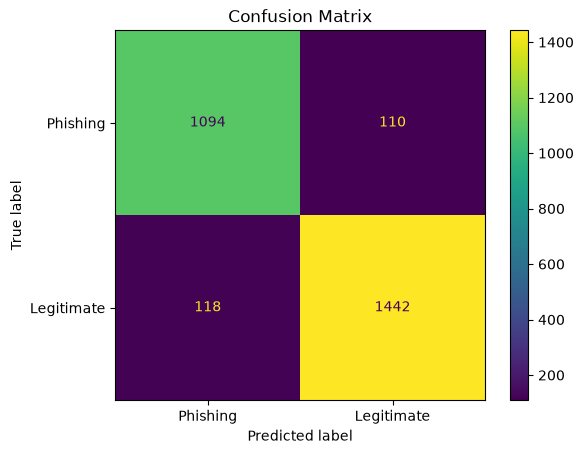

In [21]:
cm = confusion_matrix(y_test, y_pred, labels=[-1, 1])

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Phishing",
        "Legitimate"
    ]
).plot()

plt.title("Confusion Matrix")
plt.show()

### Valitun päätöspuun visualisointi

Värikoodattu puu auttaa selkeyttämään milloin sivu on phishing ja milloin ei. Värit on kylmistä (legitimate) lämpimiin (phishing)

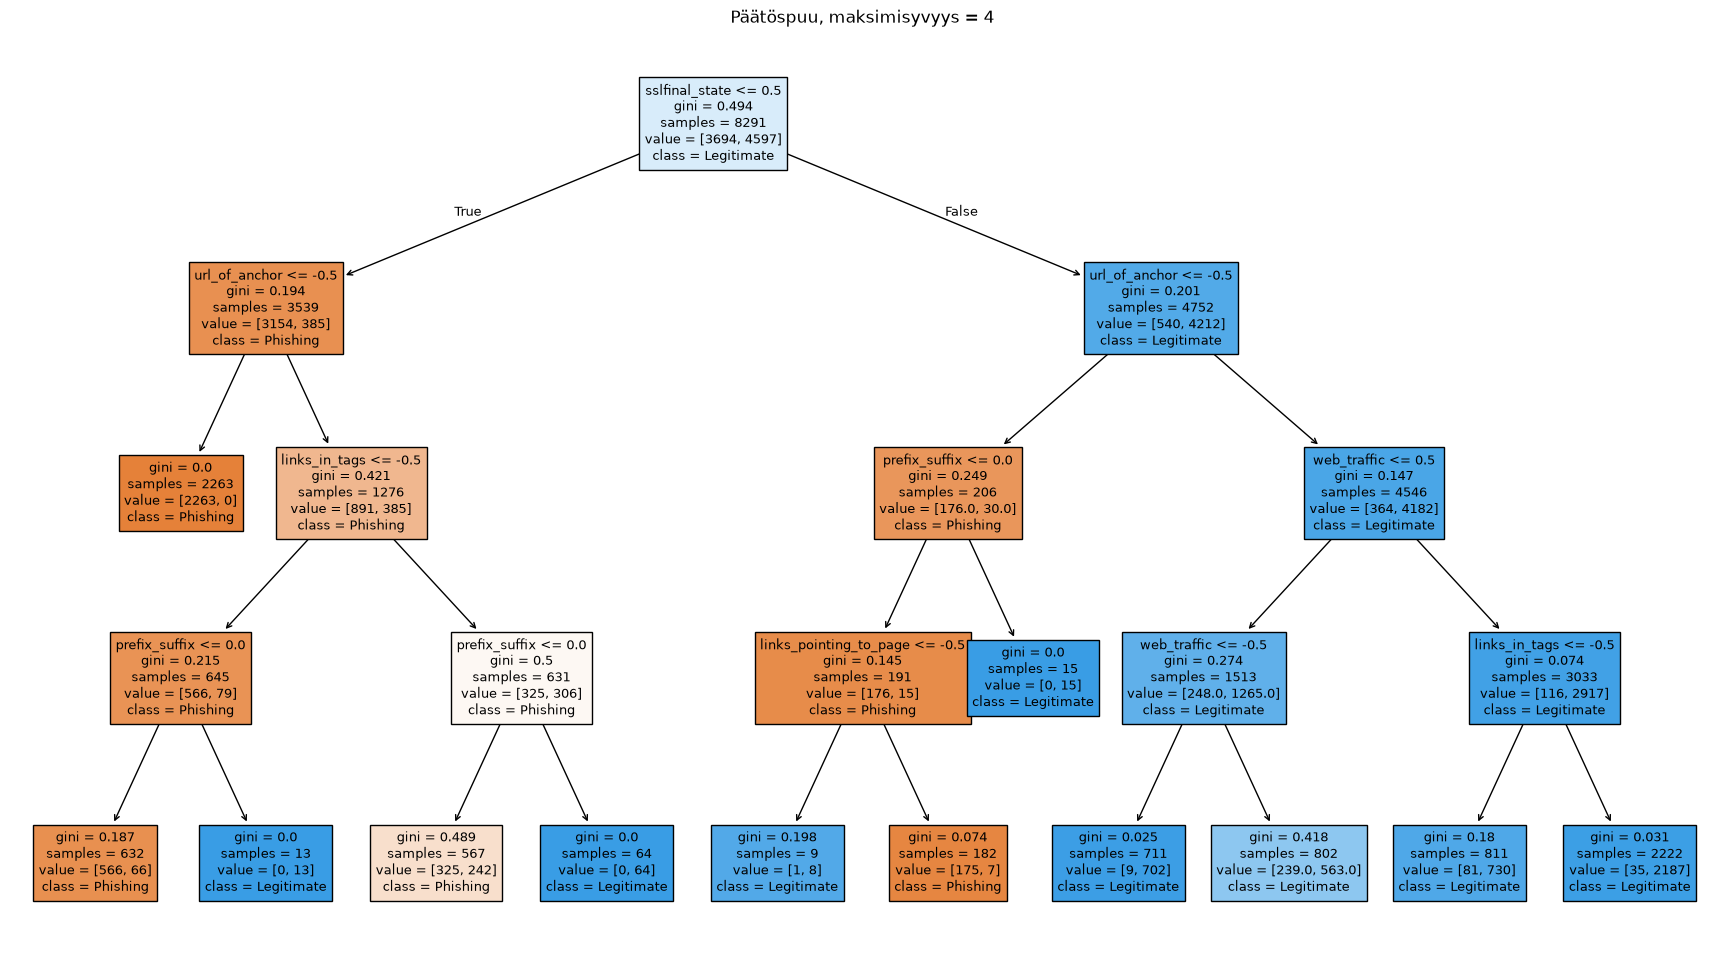

In [22]:
plt.figure(figsize=(22, 12))

plot_tree(
    final_model,
    feature_names=x.columns,
    class_names=[
        "Phishing",
        "Legitimate"
    ],
    filled=True,
    fontsize=9
)

plt.title(f"Päätöspuu, maksimisyvyys = {FINAL_MAX_DEPTH}")

plt.show()

# 6. Deployment

### Ohjeet IT asiantuntijalle

Aloita päätöspuun yläosasta ja tarkista solmussa näkyvä ominaisuus.

- Jos ehto on tosi, seuraa vasenta haaraa.
- Jos ehto on epätosi, seuraa oikeaa haaraa.
- Jatka, kunnes saavut lehtisolmuun.
- Lehtisolmu kertoo lopullisen ennusteen.

Ennustus:

- '-1' = phishing, lämpimät värit (ornssi ja sen lähellä olevat)
- '1' = legitimate, kylmät värit (sinisen sävyt)

# Osa 2 satunnaispuut

# 1. Business understanding

Yllä valittiin järkevä päätöspuumalli ja annettiin ohjeet IT-asiantutijalle kuinka sitä käytetään. Tässä osassa tehdään satunnaismetsä, jossa saadaan tarkempi ennuste onko sivu phishing vai legitimate.

# 2. Data understanding


Phishing Websites -aineisto ladataan UCI Machine Learning Repositorysta.

Kohdemuuttuja on Result.

Ennen mallin rakentamista aineistoa tutkitaan, jotta saadaan käsitys seuraavista asioista:

- havaintojen määrä
- selittävien muuttujien määrä
- muuttujien nimet
- datatyypit
- puuttuvat arvot
- kohdemuuttujan luokkajakauma

In [23]:
# metadata 
print(phishing_websites.metadata) 
  
# variable information 
print(phishing_websites.variables) 

{'uci_id': 327, 'name': 'Phishing Websites', 'repository_url': 'https://archive.ics.uci.edu/dataset/327/phishing+websites', 'data_url': 'https://archive.ics.uci.edu/static/public/327/data.csv', 'abstract': 'This dataset collected mainly from: PhishTank archive, MillerSmiles archive, Googleâ€™s searching operators.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 11055, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['result'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Tue Mar 05 2024', 'dataset_doi': '10.24432/C51W2X', 'creators': ['Rami Mohammad', 'Lee McCluskey'], 'intro_paper': {'ID': 396, 'type': 'NATIVE', 'title': 'An assessment of features related to phishing websites using an automated technique', 'authors': 'R. Mohammad, F. Thabtah, L. Mccluskey', 'venue': 'International Conference for Internet Tec

In [24]:
df = pd.concat([x, y], axis=1)

df.dtypes

having_ip_address             int64
url_length                    int64
shortining_service            int64
having_at_symbol              int64
double_slash_redirecting      int64
prefix_suffix                 int64
having_sub_domain             int64
sslfinal_state                int64
domain_registration_length    int64
favicon                       int64
port                          int64
https_token                   int64
request_url                   int64
url_of_anchor                 int64
links_in_tags                 int64
sfh                           int64
submitting_to_email           int64
abnormal_url                  int64
redirect                      int64
on_mouseover                  int64
rightclick                    int64
popupwindow                   int64
iframe                        int64
age_of_domain                 int64
dnsrecord                     int64
web_traffic                   int64
page_rank                     int64
google_index                

### Targetin muuttujat

Targetin muuttuja 'Result' viittaa onko sivu phisingiä vai ei. Arvo '1' tarkoittaa että sivu ei ole phising ja arvo '-1' tarkoittaa sivu on phisingiä.

Tarkastellaan enne splittingiä dataa:

## Puuttuvat arvot

Tutkitaan ja varmistetaan että datassa ei ole puuttuvia arvoja.

In [25]:
print("Target muuttujat:")
display(y.head())

Target muuttujat:


0   -1
1   -1
2   -1
3   -1
4    1
Name: result, dtype: int64

In [26]:
print("Target arvojen summa:")
display(y.value_counts())

Target arvojen summa:


result
 1    6157
-1    4898
Name: count, dtype: int64

In [27]:
print("Target luokan jakauma:")
display(y.value_counts(normalize=True))

Target luokan jakauma:


result
 1    0.556943
-1    0.443057
Name: proportion, dtype: float64

## 3. Data preparation

Ei tarvitse skaalausta kun luokkien jakauma on lähes sama.

Selittävät arvot ovat jo numeerisia eli ei tarvitse muuttaa dataa.

Data jaetaan koulutus- ja testausdataan käyttäen hold-out tekniikkaa:

- 75% käytetään koulutukseen
- 25% käytetään testaamiseen

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state=20)

print("Koulutuksen luokkajakauma")
display(y_train.value_counts(normalize=True))

print("Testauksen luokkajakauma:")
display(y_test.value_counts(normalize=True))

Koulutuksen luokkajakauma


result
 1    0.554457
-1    0.445543
Name: proportion, dtype: float64

Testauksen luokkajakauma:


result
 1    0.564399
-1    0.435601
Name: proportion, dtype: float64

## 4. Modeling

### Metsän arvojen valinta

Valitaan parhaat parametrit mallia varten:
- max samples arvoilla: 0.6, 0.65, 0.7, 0.75, 0.8, 0.85
- max features arvoilla: 0.3, 0.5, 0.7, 0.75, 1.0

In [29]:
max_samples_values = [0.6, 0.65, 0.7, 0.75, 0.8, 0.85]
max_features_values = [0.3, 0.5, 0.7, 0.75, 1.0]

results = []

for max_samples in max_samples_values:
    for max_features in max_features_values:
        model = RandomForestClassifier(n_estimators=100, bootstrap=True, max_samples=max_samples, max_features=max_features, random_state=123)
        
        cv_scores = cross_val_score(model, x_train, y_train, cv=10)
    
        results.append({
                "max_samples": max_samples,
                "max_features": max_features,
                "accuracy": cv_scores.mean()
            })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "accuracy",
        ascending=False
    )
)

,max_samples,max_features,accuracy
25,0.85,0.30,0.967195
15,0.75,0.30,0.967074
20,0.80,0.30,0.967074
26,0.85,0.50,0.966953
10,0.70,0.30,0.966953
5,0.65,0.30,0.966833
0,0.60,0.30,0.966471
11,0.70,0.50,0.966350
6,0.65,0.50,0.965988
16,0.75,0.50,0.965988


### Valinta

Accuracy arvojen perusteella järkevin valinta on:
- max_samples: 0.75
    - Tällöin ei kouluteta lähes koko datalla vaan standarilla n. kolmasosa testidataksi.
- max_features: 0.30
    - Sillä saatiin parhaat testitulokset ajettua joka vaiheelta

# 5. Evaluation

Arvioidaan viimeisen valitun satunnaismetsä laskemalla metriikat:

- Tarkkuus (accuracy)
- Täsmällisyys (precision)
- Saanto (recall)
- F1-score

Verrataan metriikat valittuun valintapuu mallin vastaaviin arvoihin.

In [30]:
final_forest_model = RandomForestClassifier(n_estimators=100, bootstrap=True, max_samples= 0.75, max_features=0.30, random_state=123)

final_forest_model.fit(x_train, y_train)

y_pred_forest = final_forest_model.predict(x_test)

In [32]:
accuracy_forest = accuracy_score(
    y_test,
    y_pred_forest
)

precision_forest = precision_score(
    y_test,
    y_pred_forest,
    pos_label=-1
)

recall_forest = recall_score(
    y_test,
    y_pred_forest,
    pos_label=-1
)

f1_forest = f1_score(
    y_test,
    y_pred_forest,
    pos_label=-1
)

accuracy_tree = accuracy_score(
    y_test,
    y_pred
)

precision_tree = precision_score(
    y_test,
    y_pred,
    pos_label=-1
)

recall_tree = recall_score(
    y_test,
    y_pred,
    pos_label=-1
)

f1_tree = f1_score(
    y_test,
    y_pred,
    pos_label=-1
)

print("Valintapuumalli:")

print(f"Tarkkuus (accuracy): {accuracy_tree:.4f}")
print(f"Phishingin täsmällisyys (precision): {precision_tree:.4f}")
print(f"Phishingin saanto (recall): {recall_tree:.4f}")
print(f"Phishingin F1-score: {f1_tree:.4f}")

print("")

print("Satunnaismetsämalli:")

print(f"Tarkkuus (accuracy): {accuracy_forest:.4f}")
print(f"Phishingin täsmällisyys (precision): {precision_forest:.4f}")
print(f"Phishingin saanto (recall): {recall_forest:.4f}")
print(f"Phishingin F1-score: {f1_forest:.4f}")

Valintapuumalli:
Tarkkuus (accuracy): 0.9175
Phishingin täsmällisyys (precision): 0.9026
Phishingin saanto (recall): 0.9086
Phishingin F1-score: 0.9056

Satunnaismetsämalli:
Tarkkuus (accuracy): 0.9761
Phishingin täsmällisyys (precision): 0.9765
Phishingin saanto (recall): 0.9684
Phishingin F1-score: 0.9725


In [33]:
print("Valintapuu: ")
print(
    classification_report(
        y_test,
        y_pred,
        labels=[-1, 1],
        target_names=[
            "Phishing",
            "Legitimate"
        ]
    )
)
print("")
print("Satunnaismetsä: ")
print(
    classification_report(
        y_test,
        y_pred_forest,
        labels=[-1, 1],
        target_names=[
            "Phishing",
            "Legitimate"
        ]
    )
)

Valintapuu: 
              precision    recall  f1-score   support

    Phishing       0.90      0.91      0.91      1204
  Legitimate       0.93      0.92      0.93      1560

    accuracy                           0.92      2764
   macro avg       0.92      0.92      0.92      2764
weighted avg       0.92      0.92      0.92      2764


Satunnaismetsä: 
              precision    recall  f1-score   support

    Phishing       0.98      0.97      0.97      1204
  Legitimate       0.98      0.98      0.98      1560

    accuracy                           0.98      2764
   macro avg       0.98      0.98      0.98      2764
weighted avg       0.98      0.98      0.98      2764



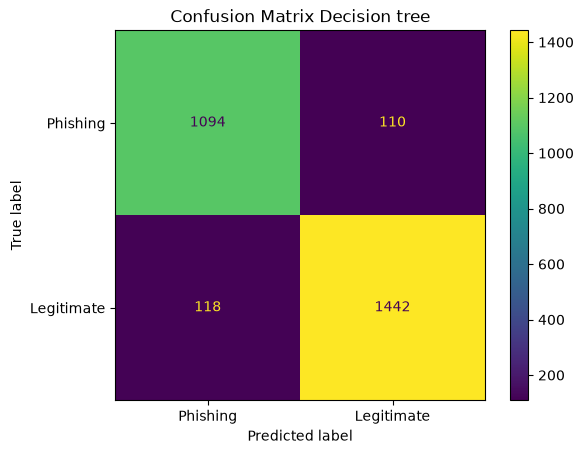

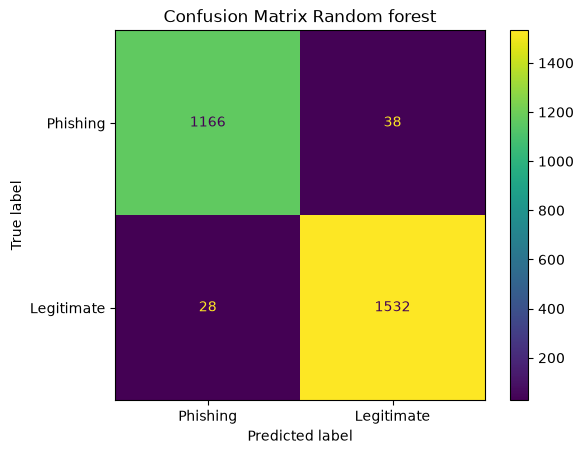

In [36]:
cm = confusion_matrix(y_test, y_pred, labels=[-1, 1])

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Phishing",
        "Legitimate"
    ]
).plot()

plt.title("Confusion Matrix Decision tree")
plt.show()

cm_forest = confusion_matrix(y_test, y_pred_forest, labels=[-1, 1])

ConfusionMatrixDisplay(
    confusion_matrix=cm_forest,
    display_labels=[
        "Phishing",
        "Legitimate"
    ]
).plot()

plt.title("Confusion Matrix Random forest")
plt.show()

## Johtopäätöksiä

Satunnaismetsän kaikki metriikat nousivat huomattavasti:

- Tarkkuus (Accuracy): 0.9175 -> 0.9761, eli kasvu 0.0586 (5.86 prosenttiyksikköä)
- Täsmällisyys (Precision): 0.9026 -> 0.9765, eli kasvu 0.0739 (7.39 prosenttiyksikköä)
- Saanto (Recall): 0.9086 -> 0.9684, eli kasvu 0.0598 (5.98 prosenttiyksikköä)
- F1-score (F1-score): 0.9056 -> 0.9725, eli kasvu 0.0669 (6.69 prosenttiyksikköä)

Myös virheluokitukset vähenivät selvästi:

- True Positive (TP): 1094 -> 1166, eli kasvu 72
- True Negative (TN): 1442 -> 1532, eli kasvu 90
- False Positive (FP): 118 -> 28, eli vähenemä 90
- False Negative (FN): 110 -> 38, eli vähenemä 72

# 6. Deployment

Satunnaismetsämallia voidaan käyttää automatisoidussa järjestelmässä, joka arvioi verkkosivun ominaisuudet ja ennustaa, onko sivu phishing- vai legitimate-sivu.

Jos malli luokittelee verkkosivun phishing-sivuksi, järjestelmä voi varoittaa käyttäjää ennen sivulle siirtymistä.

Mallin toimintaa tulee seurata käytön aikana ja sen suorituskykyä arvioida uudelleen uudella datalla.